In [1]:
## Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
## Read survey data into pandas DataFrame
FILE_PATH = "results.csv"


df = pd.read_csv(FILE_PATH, low_memory=False)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49191 entries, 0 to 49190
Columns: 172 entries, ResponseId to JobSat
dtypes: float64(52), int64(1), object(119)
memory usage: 64.6+ MB


In [3]:
df.head()   

,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,...,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,Vertex AI,NaN,NaN,NaN,ChatGPT,NaN,When I don’t trust AI’s answers,"Troubleshooting, profiling, debugging",61256.0,10.0
1,2,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,NaN,2.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers;When I want to...,All skills. AI is a flop.,104413.0,9.0
2,3,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-em...",None of the above,10.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code;GitHub Copilot;Google Gemini,NaN,When I don’t trust AI’s answers;When I want to...,"Understand how things actually work, problem s...",53061.0,8.0
3,4,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,None of the above,4.0,"Yes, I am not new to coding but am learning ne...","Other online resources (e.g. standard search, ...","Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code,NaN,When I don’t trust AI’s answers;When I want to...,NaN,36197.0,6.0
4,5,I am a developer by profession,35-44 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Independent contractor, freelancer, or self-em...","Caring for dependents (children, elderly, etc.)",21.0,"No, I am not new to coding and did not learn n...",NaN,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers,"critical thinking, the skill to define the tas...",60000.0,7.0


In [4]:
## Check that the important columns exist
required_columns = [
    'Employment',
    'Country',
    'EdLevel',
    'YearsCodePro',
    'DevType',
    'RemoteWork',
    'OrgSize',
    'Industry',
    'ConvertedCompYearly'
]

missing_columns = [col for col in required_columns if col not in df.columns]

print("Missing columns:", missing_columns)

Missing columns: ['YearsCodePro']


In [5]:
## Keep only full-time employed respondents
## This makes salary comparisons more fair and meaningful

df = df[df['Employment'].str.contains('Employed', case=False, na=False)]

df.shape

(42685, 172)

In [6]:
## Keep only the selected features and target column
selected_columns = [
    'Country',
    'EdLevel',
    'YearsCode',
    'DevType',
    'RemoteWork',
    'OrgSize',
    'Industry',
    'ConvertedCompYearly'
]

df = df[selected_columns].copy()

df.head()

,Country,EdLevel,YearsCode,DevType,RemoteWork,OrgSize,Industry,ConvertedCompYearly
0,Ukraine,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",14.0,"Developer, mobile",Remote,20 to 99 employees,Fintech,61256.0
1,Netherlands,"Associate degree (A.A., A.S., etc.)",10.0,"Developer, back-end","Hybrid (some in-person, leans heavy to flexibi...",500 to 999 employees,Retail and Consumer Services,104413.0
2,Ukraine,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",12.0,"Developer, front-end",NaN,NaN,Software Development,53061.0
3,Ukraine,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",5.0,"Developer, back-end",Remote,"10,000 or more employees",Retail and Consumer Services,36197.0
4,Ukraine,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",22.0,Engineering manager,NaN,NaN,Software Development,60000.0


In [7]:
## Check for missing data
df.isna().sum()

Country                11130
EdLevel                  113
YearsCode               4318
DevType                 3874
RemoteWork             10024
OrgSize                 9647
Industry               10024
ConvertedCompYearly    19631
dtype: int64

In [8]:
# Keep employed responses and remove only missing/invalid salary values
df = df.copy()

df['ConvertedCompYearly'] = pd.to_numeric(
    df['ConvertedCompYearly'],
    errors='coerce'
)

df = df.dropna(subset=['ConvertedCompYearly'])
df = df[df['ConvertedCompYearly'] >= 0].copy()

In [9]:
## Clean data

## Remove rows with missing values in the selected columns
df = df.dropna()

## Convert years of professional coding experience into numbers
df['YearsCode'] = df['YearsCode'].replace({
    'Less than 1 year': 0.5,
    'More than 50 years': 51
})

df['YearsCode'] = pd.to_numeric(df['YearsCode'], errors='coerce')

## Remove rows that could not be converted
df = df.dropna()

## Keep only positive salary values
df = df[df['ConvertedCompYearly'] > 0]

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20517 entries, 0 to 49122
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Country              20517 non-null  object 
 1   EdLevel              20517 non-null  object 
 2   YearsCode            20517 non-null  float64
 3   DevType              20517 non-null  object 
 4   RemoteWork           20517 non-null  object 
 5   OrgSize              20517 non-null  object 
 6   Industry             20517 non-null  object 
 7   ConvertedCompYearly  20517 non-null  float64
dtypes: float64(2), object(6)
memory usage: 1.4+ MB


In [10]:
check_columns = [
    'Country', 'Currency', 'CompTotal',
    'ConvertedCompYearly', 'Employment', 'WorkExp', 'DevType'
]

print('Lowest salaries:')
display(df.sort_values('ConvertedCompYearly')[['Country', 'ConvertedCompYearly', 'DevType']].head(10))

print('Highest salaries:')
display(df.sort_values('ConvertedCompYearly', ascending=False)[check_columns].head(10))

Lowest salaries:


,Country,ConvertedCompYearly,DevType
13304,India,1.0,"Developer, full-stack"
48600,Nomadic,1.0,Cybersecurity or InfoSec professional
12407,Indonesia,1.0,"Developer, back-end"
20026,Turkey,1.0,DevOps engineer or professional
1764,Viet Nam,1.0,"Developer, front-end"
26961,India,1.0,"Developer, front-end"
34865,Antigua and Barbuda,1.0,"Developer, full-stack"
32345,Viet Nam,1.0,"Developer, full-stack"
9012,Turkey,1.0,"Developer, AI apps or physical AI"
47176,Ukraine,1.0,"Developer, QA or test"


Highest salaries:


KeyError: "['Currency', 'CompTotal', 'Employment', 'WorkExp'] not in index"

In [11]:
## Reduce categories so the model and Streamlit app stay manageable

categorical_to_group = ['Country', 'DevType', 'Industry']

top_categories = {}

for col in categorical_to_group:
    top_categories[col] = df[col].value_counts().head(15).index
    
    df[col] = df[col].where(
        df[col].isin(top_categories[col]),
        'Other'
    )

df.head()

,Country,EdLevel,YearsCode,DevType,RemoteWork,OrgSize,Industry,ConvertedCompYearly
0,Ukraine,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",14.0,"Developer, mobile",Remote,20 to 99 employees,Fintech,61256.0
1,Netherlands,"Associate degree (A.A., A.S., etc.)",10.0,"Developer, back-end","Hybrid (some in-person, leans heavy to flexibi...",500 to 999 employees,Retail and Consumer Services,104413.0
3,Ukraine,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",5.0,"Developer, back-end",Remote,"10,000 or more employees",Retail and Consumer Services,36197.0
7,Ukraine,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)",30.0,"Architect, software or solutions",Remote,Less than 20 employees,Software Development,72000.0
8,Ukraine,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",15.0,Data engineer,Remote,"5,000 to 9,999 employees",Banking/Financial Services,70000.0


In [12]:
## Understand the type of variable for each column
df.describe(include='all')

,Country,EdLevel,YearsCode,DevType,RemoteWork,OrgSize,Industry,ConvertedCompYearly
count,20517,20517,20517.000000,20517,20517,20517,20517,2.051700e+04
unique,16,8,NaN,16,5,9,15,NaN
top,Other,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",NaN,"Developer, full-stack",Remote,20 to 99 employees,Software Development,NaN
freq,5720,9189,NaN,6487,7000,4165,9342,NaN
mean,NaN,NaN,17.594483,NaN,NaN,NaN,NaN,1.014351e+05
std,NaN,NaN,10.677736,NaN,NaN,NaN,NaN,3.386068e+05
min,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,1.000000e+00
25%,NaN,NaN,10.000000,NaN,NaN,NaN,NaN,4.184600e+04
50%,NaN,NaN,15.000000,NaN,NaN,NaN,NaN,7.715000e+04
75%,NaN,NaN,25.000000,NaN,NaN,NaN,NaN,1.234820e+05


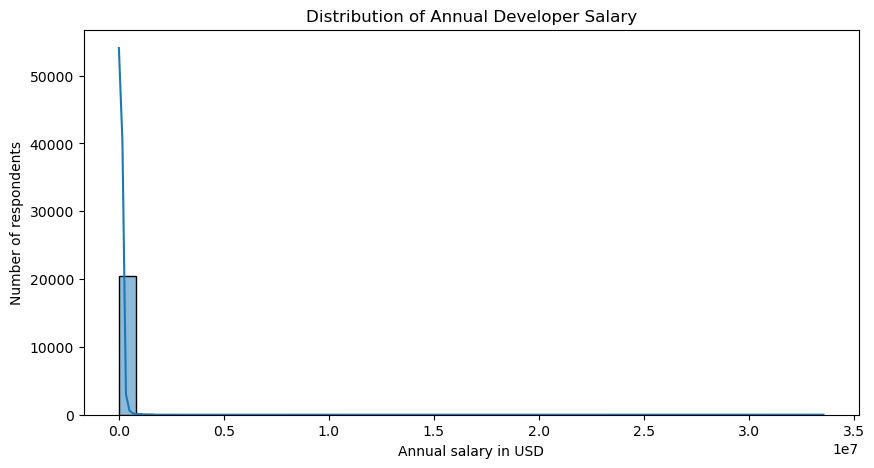

In [13]:
## Describe data distribution

plt.figure(figsize=(10, 5))

sns.histplot(df['ConvertedCompYearly'], bins=40, kde=True)

plt.title('Distribution of Annual Developer Salary')
plt.xlabel('Annual salary in USD')
plt.ylabel('Number of respondents')

plt.show()

In [14]:
## Understanding distribution of categorical features

col_categorical = df.select_dtypes(include=['object']).columns

for col in col_categorical:
    print(f'\n{col} ({df[col].nunique()} categories)')
    print(df[col].value_counts().head(15))


Country (16 categories)
Country
Other                                                   5720
United States of America                                4679
Germany                                                 1840
United Kingdom of Great Britain and Northern Ireland    1317
India                                                    960
France                                                   858
Canada                                                   788
Ukraine                                                  590
Brazil                                                   539
Netherlands                                              536
Italy                                                    494
Australia                                                485
Spain                                                    484
Poland                                                   441
Sweden                                                   414
Name: count, dtype: int64

EdLevel (8 categories)
Ed

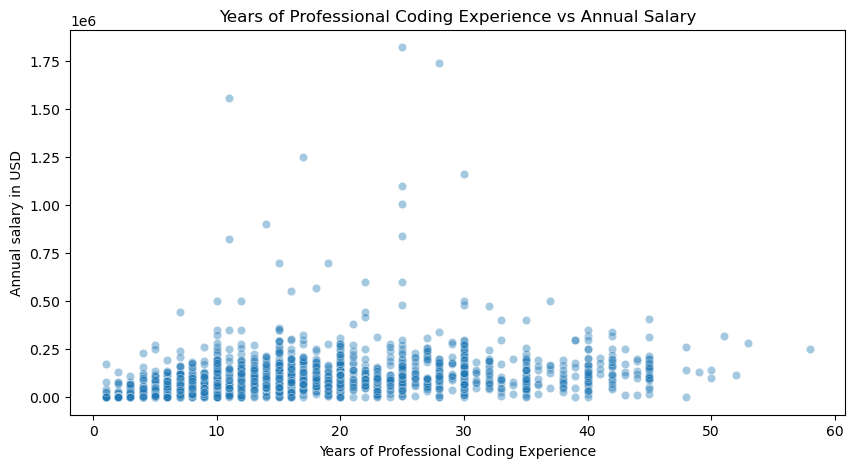

In [15]:
## Understanding relationship between experience and salary

plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=df.sample(min(2000, len(df)), random_state=67),
    x='YearsCode',
    y='ConvertedCompYearly',
    alpha=0.4
)

plt.title('Years of Professional Coding Experience vs Annual Salary')
plt.xlabel('Years of Professional Coding Experience')
plt.ylabel('Annual salary in USD')

plt.show()

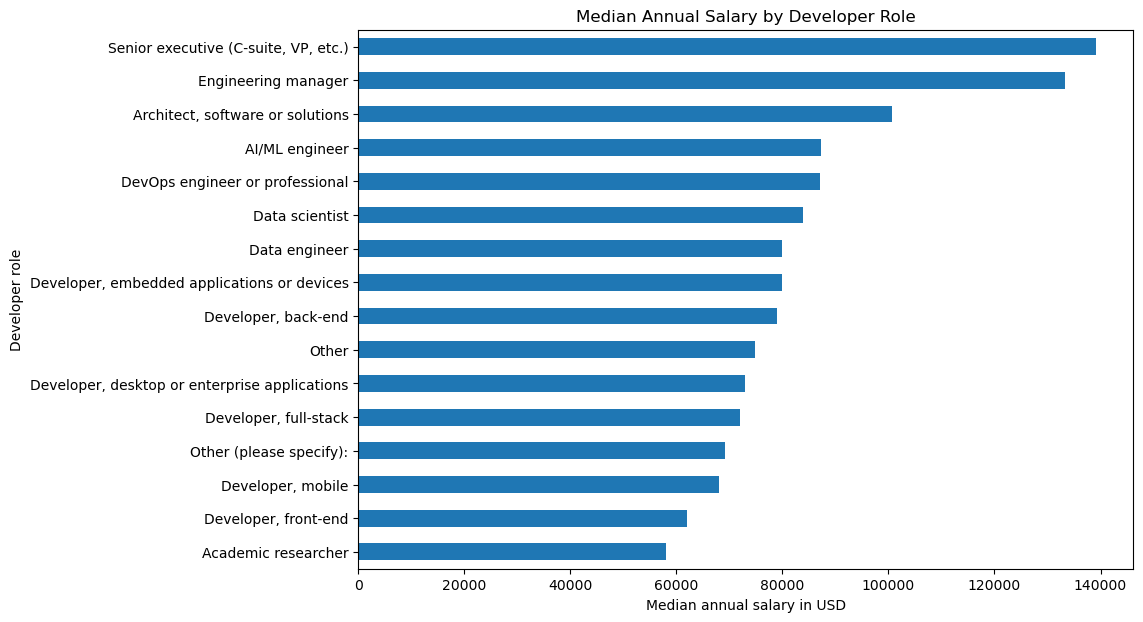

In [16]:
## Understanding median salary by developer role

median_salary_by_role = (
    df.groupby('DevType')['ConvertedCompYearly']
    .median()
    .sort_values()
)

plt.figure(figsize=(10, 7))

median_salary_by_role.plot(kind='barh')

plt.title('Median Annual Salary by Developer Role')
plt.xlabel('Median annual salary in USD')
plt.ylabel('Developer role')

plt.show()

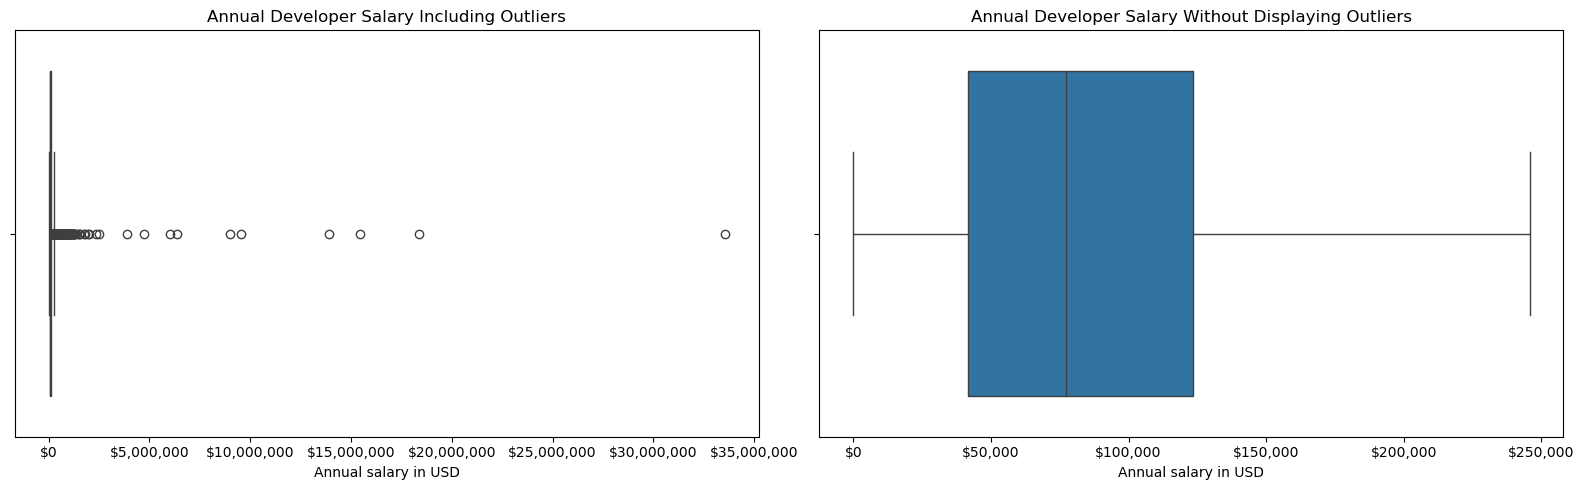

In [17]:
## Box-and-whisker plot of annual developer salary

from matplotlib.ticker import StrMethodFormatter

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

## Left: show every value, including extreme outliers
sns.boxplot(
    x=df['ConvertedCompYearly'],
    ax=axes[0]
)

axes[0].set_title('Annual Developer Salary Including Outliers')
axes[0].set_xlabel('Annual salary in USD')
axes[0].xaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))

## Right: hide outlier points to clearly show typical salaries
sns.boxplot(
    x=df['ConvertedCompYearly'],
    showfliers=False,
    ax=axes[1]
)

axes[1].set_title('Annual Developer Salary Without Displaying Outliers')
axes[1].set_xlabel('Annual salary in USD')
axes[1].xaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))

plt.tight_layout()
plt.show()

In [18]:
## Clean data for machine learning

x = df.drop(columns=['ConvertedCompYearly'])

## Convert categorical values into numerical columns
x = pd.get_dummies(x, drop_first=True)

y = df['ConvertedCompYearly']

x.head()    

,YearsCode,Country_Brazil,Country_Canada,Country_France,Country_Germany,Country_India,Country_Italy,Country_Netherlands,Country_Other,Country_Poland,...,Industry_Healthcare,Industry_Higher Education,Industry_Insurance,"Industry_Internet, Telecomm or Information Services",Industry_Manufacturing,Industry_Media & Advertising Services,Industry_Other:,Industry_Retail and Consumer Services,Industry_Software Development,"Industry_Transportation, or Supply Chain"
0,14.0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,10.0,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
3,5.0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
7,30.0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
8,15.0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [19]:
## Split data into train set and test set

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=67
)

print(x_train.shape)
print(x_test.shape)

(16413, 64)
(4104, 64)


In [20]:
## Baseline model

from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, mean_squared_error, r2_score

dummy = DummyRegressor(strategy='mean')

dummy.fit(x_train, y_train)

y_pred_dummy = dummy.predict(x_test)

print(f'MAE: {mean_absolute_error(y_test, y_pred_dummy)}')
print(f'RMSE: {root_mean_squared_error(y_test, y_pred_dummy)}')
print(f'MSE: {mean_squared_error(y_test, y_pred_dummy)}')
print(f'R2: {r2_score(y_test, y_pred_dummy)}')

MAE: 63806.38817873828
RMSE: 127546.57937202869
MSE: 16268129909.505213
R2: -0.00068540392487626


In [21]:
## Initialise and train Decision Tree model

from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(random_state=67)

tree.fit(x_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",67
,"max_l

In [22]:
## Evaluate Decision Tree model

y_pred_tree = tree.predict(x_test)

print(f'MAE: {mean_absolute_error(y_test, y_pred_tree)}')
print(f'RMSE: {root_mean_squared_error(y_test, y_pred_tree)}')
print(f'MSE: {mean_squared_error(y_test, y_pred_tree)}')
print(f'R2: {r2_score(y_test, y_pred_tree)}')

MAE: 62597.85272150283
RMSE: 277979.98184762045
MSE: 77272870308.00339
R2: -3.7532097338009747


In [23]:
## Initialise and train Gradient Boosting model

from sklearn.ensemble import GradientBoostingRegressor

gtree = GradientBoostingRegressor(random_state=67)

gtree.fit(x_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [24]:
## Evaluate Gradient Boosting model

y_pred_gtree = gtree.predict(x_test)

print(f'MAE: {mean_absolute_error(y_test, y_pred_gtree)}')
print(f'RMSE: {root_mean_squared_error(y_test, y_pred_gtree)}')
print(f'MSE: {mean_squared_error(y_test, y_pred_gtree)}')
print(f'R2: {r2_score(y_test, y_pred_gtree)}')

MAE: 45942.045423291886
RMSE: 123727.06600909538
MSE: 15308386863.219046
R2: 0.058350321956302964


In [25]:
## Initialise and train Random Forest model

from sklearn.ensemble import RandomForestRegressor

rtree = RandomForestRegressor(
    n_estimators=100,
    random_state=67,
    n_jobs=-1
)

rtree.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [26]:
## Evaluate Random Forest model

y_pred_rtree = rtree.predict(x_test)

print(f'MAE: {mean_absolute_error(y_test, y_pred_rtree)}')
print(f'RMSE: {root_mean_squared_error(y_test, y_pred_rtree)}')
print(f'MSE: {mean_squared_error(y_test, y_pred_rtree)}')
print(f'R2: {r2_score(y_test, y_pred_rtree)}')

MAE: 51764.93850388466
RMSE: 179997.89075808585
MSE: 32399240677.35981
R2: -0.9929424847498756


In [27]:
## Compare all models

results = pd.DataFrame({
    'Model': ['Baseline', 'Decision Tree', 'Gradient Boosting', 'Random Forest'],
    'MAE': [
        mean_absolute_error(y_test, y_pred_dummy),
        mean_absolute_error(y_test, y_pred_tree),
        mean_absolute_error(y_test, y_pred_gtree),
        mean_absolute_error(y_test, y_pred_rtree)
    ],
    'RMSE': [
        root_mean_squared_error(y_test, y_pred_dummy),
        root_mean_squared_error(y_test, y_pred_tree),
        root_mean_squared_error(y_test, y_pred_gtree),
        root_mean_squared_error(y_test, y_pred_rtree)
    ],
    'R2': [
        r2_score(y_test, y_pred_dummy),
        r2_score(y_test, y_pred_tree),
        r2_score(y_test, y_pred_gtree),
        r2_score(y_test, y_pred_rtree)
    ]
})

results.sort_values(by='MAE')

,Model,MAE,RMSE,R2
2,Gradient Boosting,45942.045423,123727.066009,0.058350
3,Random Forest,51764.938504,179997.890758,-0.992942
1,Decision Tree,62597.852722,277979.981848,-3.753210
0,Baseline,63806.388179,127546.579372,-0.000685


In [28]:
## Tune Random Forest using RandomizedSearchCV

from sklearn.model_selection import RandomizedSearchCV

param_dist_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestRegressor(
    random_state=67,
    n_jobs=-1
)

rs_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist_rf,
    n_iter=10,
    cv=3,
    scoring='neg_mean_absolute_error',
    random_state=67,
    n_jobs=-1
)

rs_rf.fit(x_train, y_train)

print(rs_rf.best_params_)

{'n_estimators': 300, 'min_samples_split': 10, 'max_features': 'log2', 'max_depth': None}


In [31]:
## Evaluate tuned Random Forest model

best_rf = rs_rf.best_estimator_

y_pred_best_rf = best_rf.predict(x_test)

print(f'MAE: {mean_absolute_error(y_test, y_pred_best_rf)}')
print(f'RMSE: {root_mean_squared_error(y_test, y_pred_best_rf)}')
print(f'MSE: {mean_squared_error(y_test, y_pred_best_rf)}')
print(f'R2: {r2_score(y_test, y_pred_best_rf)}')
print(best_rf)

MAE: 46232.00415436652
RMSE: 124173.78389603137
MSE: 15419128607.058298
R2: 0.05153837446869536
RandomForestRegressor(max_features='log2', min_samples_split=10,
                      n_estimators=300, n_jobs=-1, random_state=67)


In [30]:
## Understand the salary range in the test data

q1 = y_test.quantile(0.25)
median_salary = y_test.median()
q3 = y_test.quantile(0.75)
iqr = q3 - q1

print(f'Minimum salary: ${y_test.min():,.0f}')
print(f'25th percentile salary: ${q1:,.0f}')
print(f'Median salary: ${median_salary:,.0f}')
print(f'75th percentile salary: ${q3:,.0f}')
print(f'Maximum salary: ${y_test.max():,.0f}')
print(f'Middle 50% salary range: ${iqr:,.0f}')

Minimum salary: $1
25th percentile salary: $42,223
Median salary: $76,422
75th percentile salary: $123,000
Maximum salary: $4,706,124
Middle 50% salary range: $80,777
